In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.1.0


# Module 2: Playing with pytorch: linear regression

[Video timestamp](https://youtu.be/Z6H3zakmn6E?t=960)

In [2]:
# Helper function to visualize the 3D plane
def plot_figs(fig_num, elev, azim, x, y, weights, bias):
    fig = plt.figure(fig_num, figsize=(4, 3))
    plt.clf()
    # Fixed for modern Matplotlib versions
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=elev, azim=azim)
    ax.scatter(x[:, 0], x[:, 1], y)
    ax.plot_surface(np.array([[0, 0], [1, 1]]),
                    np.array([[0, 1], [0, 1]]),
                    (np.dot(np.array([[0, 0, 1, 1],
                                          [0, 1, 0, 1]]).T, weights) + bias).reshape((2, 2)),
                    alpha=.5)
    ax.set_xlabel('x_1')
    ax.set_ylabel('x_2')
    ax.set_zlabel('y')
    
def plot_views(x, y, w, b):
    elev = 43.5
    azim = -110
    plot_figs(1, elev, azim, x, y, w, b[0])
    plt.show()

## Warm-up: Linear regression with numpy

Our model is:
$$
y_t = 2x^1_t-3x^2_t+1, \quad t\in\{1,\dots,30\}
$$

Our task is given the 'observations' $(x_t,y_t)_{t\in\{1,\dots,30\}}$ to recover the weights $w^1=2, w^2=-3$ and the bias $b = 1$.

In order to do so, we will solve the following optimization problem:
$$
\underset{w^1,w^2,b}{\operatorname{argmin}} \sum_{t=1}^{30} \left(w^1x^1_t+w^2x^2_t+b-y_t\right)^2
$$

[Video timestamp](https://youtu.be/Z6H3zakmn6E?t=1080)

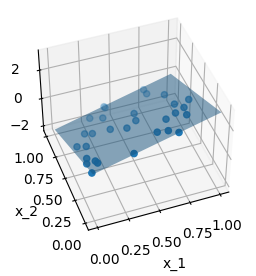

In [3]:
from numpy.random import random

# Generate 30 random samples with 2 features
x = random((30,2))

# Generate ground truth labels: y = 2*x1 - 3*x2 + 1
y = np.dot(x, [2., -3.]) + 1.

# Ground truth parameters for visualization
w_source = np.array([2., -3.])
b_source  = np.array([1.])

# Visualize the data
plot_views(x, y, w_source, b_source)

In vector form, we define:
$$
\hat{y}_t = {\bf w}^T{\bf x}_t+b
$$
and we want to minimize the loss given by:
$$
loss = \sum_t\underbrace{\left(\hat{y}_t-y_t \right)^2}_{loss_t}.
$$

To minimize the loss we first compute the gradient of each $loss_t$:
\begin{eqnarray*}
\frac{\partial{loss_t}}{\partial w^1} &=& 2x^1_t\left({\bf w}^T{\bf x}_t+b-y_t \right)\\
\frac{\partial{loss_t}}{\partial w^2} &=& 2x^2_t\left({\bf w}^T{\bf x}_t+b-y_t \right)\\
\frac{\partial{loss_t}}{\partial b} &=& 2\left({\bf w}^T{\bf x}_t+b-y_t \right)
\end{eqnarray*}

Note that the actual gradient of the loss is given by:
$$
\frac{\partial{loss}}{\partial w^1} =\sum_t \frac{\partial{loss_t}}{\partial w^1},\quad
\frac{\partial{loss}}{\partial w^2} =\sum_t \frac{\partial{loss_t}}{\partial w^2},\quad
\frac{\partial{loss}}{\partial b} =\sum_t \frac{\partial{loss_t}}{\partial b}
$$

For one epoch, **(Batch) Gradient Descent** updates the weights and bias as follows:
\begin{eqnarray*}
w^1_{new}&=&w^1_{old}-\alpha\frac{\partial{loss}}{\partial w^1} \\
w^2_{new}&=&w^2_{old}-\alpha\frac{\partial{loss}}{\partial w^2} \\
b_{new}&=&b_{old}-\alpha\frac{\partial{loss}}{\partial b},
\end{eqnarray*}

and then we run several epochs.

In [5]:
# Random initialization
w_init = random(2)
b_init = random(1)
w = w_init
b = b_init

print("Initial parameters:", w, b)

Initial parameters: [0.59623128 0.75064327] [0.61949676]


In [ ]:
# --- TODO 1: Implement the Forward Pass and Loss ---
def forward(x):
    # TODO: return the dot product of x and w, plus b
    return # YOUR CODE HERE

def loss(x, y):
    # TODO: Calculate squared error between prediction and y
    y_pred = forward(x)
    return # YOUR CODE HERE

print("Initial loss:", np.sum([loss(x_val,y_val) for x_val, y_val in zip(x, y)]))

# --- TODO 2: Implement the Gradient Calculation ---
def gradient(x, y):
    # TODO: Implement the math formulas for derivatives
    # Should return a tuple: (gradient_w, gradient_b)
    
    y_pred = forward(x)
    err = y_pred - y
    
    grad_w = # YOUR CODE HERE 
    grad_b = # YOUR CODE HERE 
    
    return grad_w, grad_b
 
learning_rate = 1e-2

# Training Loop
for epoch in range(10):
    grad_w = np.array([0,0])
    grad_b = np.array(0)
    l = 0
    
    # Accumulate gradients for the batch
    for x_val, y_val in zip(x, y):
        g_w, g_b = gradient(x_val, y_val)
        grad_w = np.add(grad_w, g_w)
        grad_b = np.add(grad_b, g_b)
        l += loss(x_val, y_val)
    
    # Update weights
    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b
    
    print(f"Epoch {epoch}: Loss {l}")

print("Estimated parameters:", w, b)


In [ ]:
plot_views(x, y, w, b)

## Linear regression with tensors

[Video timestamp](https://youtu.be/Z6H3zakmn6E?t=1650)

In [9]:
dtype = torch.FloatTensor
# dtype = torch.cuda.FloatTensor # Uncomment this to run on GPU

In [10]:
x_t = torch.from_numpy(x).type(dtype)
y_t = torch.from_numpy(y).type(dtype).unsqueeze(1)

print(f"X shape: {x_t.shape}, Y shape: {y_t.shape}")

X shape: torch.Size([30, 2]), Y shape: torch.Size([30, 1])


This is an implementation of **(Batch) Gradient Descent** with tensors.

Note that in the main loop, the functions loss_t and gradient_t are always called with the same inputs: they can easily be incorporated into the loop (we'll do that below).

In [ ]:
# Initialize tensors for weights and bias
w_init_t = torch.from_numpy(w_init).type(dtype)
b_init_t = torch.from_numpy(b_init).type(dtype)

# We clone them to keep the originals safe
w_t = w_init_t.clone().unsqueeze(1)
b_t = b_init_t.clone().unsqueeze(1)

print("Initial parameters:", w_t, b_t)

# --- TODO 2.1: Translate Math to PyTorch Operations ---

def forward_t(x):
    # TODO: Use .mm() for matrix multiplication instead of np.dot or *
    return # YOUR CODE HERE 

def loss_t(x, y):
    # TODO: Calculate sum of squared errors using .pow(2) and .sum()
    y_pred = forward_t(x)
    return # YOUR CODE HERE

def gradient_t(x, y): 
    # TODO: Implement the manual gradient formulas using PyTorch operations    
    y_pred = forward_t(x)
    error = y_pred - y
    
    # HINT: creating the transpose of x is torch.t(x)
    grad_w = # YOUR CODE HERE
    grad_b = # YOUR CODE HERE
    
    return grad_w, grad_b

learning_rate = 1e-2

print("--- Starting Tensor Training (Manual) ---")

for epoch in range(10):
    # 1. Compute Loss
    l_t = loss_t(x_t, y_t)
    
    # 2. Compute Gradients manually
    grad_w, grad_b = gradient_t(x_t, y_t)
    
    # 3. Update weights manually
    w_t = w_t - learning_rate * grad_w
    b_t = b_t - learning_rate * grad_b
    
    print(f"Epoch {epoch}: Loss {l_t.item()}")

print("Estimated parameters:", w_t, b_t)

## Linear regression with Autograd

[Video timestamp](https://youtu.be/Z6H3zakmn6E?t=1890)

In [ ]:
# Setting requires_grad=True indicates that we want to compute gradients with
# respect to these Tensors during the backward pass.
w_v = torch.from_numpy(w_init).type(dtype).unsqueeze(1)
w_v.requires_grad_(True)
b_v = torch.from_numpy(b_init).type(dtype).unsqueeze(1)
b_v.requires_grad_(True)

In [ ]:
learning_rate = 1e-2

for epoch in range(10):
    # --- TODO 3: The Autograd Training Loop ---
    
    # 1. Forward Pass: Compute predicted y
    y_pred = # YOUR CODE HERE 
    
    # 2. Compute Loss (Sum of squared errors)
    loss = # YOUR CODE HERE
    
    # 3. Backward Pass: Compute gradients automatically
    # Use autograd to compute the backward pass. This call will compute the
    # gradient of loss with respect to all Variables with requires_grad=True.
    # After this call, w.grad and b.grad will be tensors holding the gradient
    # of the loss with respect to w and b respectively.
    
    # YOUR CODE HERE
    
    # 4. Update Weights
    # For this step we just want to mutate
    # the values of w_v and b_v in-place; we don't want to build up a computational
    # graph for the update steps, so we use the torch.no_grad() context manager
    # to prevent PyTorch from building a computational graph for the updates
    with torch.no_grad():
        # TODO: Update w_v and b_v using their .grad attributes
        w_v -= learning_rate * w_v.grad
        b_v -= # YOUR CODE HERE
    
    # 5. Zero Gradients
    # TODO: Manually set gradients to zero for the next iteration
    # HINT: use .grad.zero_()
    
    # YOUR CODE HERE
    
    print(f"Epoch {epoch}: Loss {loss.item()}")

print("Estimated parameters:", w_v.data, b_v.data)

## Linear regression with neural network

[Video timestamp](https://youtu.be/Z6H3zakmn6E?t=2075)

An implementation of **(Batch) Gradient Descent** using the nn package. Here we have a super simple model with only one layer and no activation function!

In [ ]:
# --- TODO 4: Define the Model ---
# Use the nn package to define our model as a sequence of layers. nn.Sequential
# is a Module which contains other Modules, and applies them in sequence to
# produce its output. Each Linear Module computes output from input using a
# linear function, and holds internal Variables for its weight and bias.

# We need a model with 2 inputs and 1 output.
model = torch.nn.Sequential(
    # TODO: Add a Linear layer here
    # torch.nn.Linear(?, ?)
)

for m in model.children():
    m.weight.data = w_init_t.clone().unsqueeze(0)
    m.bias.data = b_init_t.clone()

# The nn package also contains definitions of popular loss functions; in this
# case we will use Mean Squared Error (MSE) as our loss function.
loss_fn = torch.nn.MSELoss(reduction='sum')

# --- TODO 5: Define the Optimizer ---
# Use SGD (Stochastic Gradient Descent)
# Pass model.parameters() and the learning_rate
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# switch to train mode
model.train()

for epoch in range(10):
    # --- TODO 6: The Optimizer Loop ---
    
    # 1. Forward pass
    # compute predicted y by passing x to the model. Module objects
    # override the __call__ operator so you can call them like functions. When
    # doing so you pass a Variable of input data to the Module and it produces
    # a Variable of output data.
    y_pred = model(x_t)
    
    # Note this operation is equivalent to: pred = model.forward(x_v)

    # 2. Compute and print loss. We pass Variables containing the predicted and true
    # values of y, and the loss function returns a Variable containing the
    # loss.
    loss = loss_fn(y_pred, y_t)
    
    # 3. Zero the gradients of model
    # YOUR CODE HERE
    
    # 4. Backward pass
    # compute gradient of the loss with respect to all the learnable
    # parameters of the model. Internally, the parameters of each Module are stored
    # in Variables with requires_grad=True, so this call will compute gradients for
    # all learnable parameters in the model.
    # YOUR CODE HERE
    
    # 5. Optimizer step (Update weights)
    # Update the weights using gradient descent. Each parameter is a Tensor, so
    # we can access its data and gradients like we did before.
    # YOUR CODE HERE
    
    print(f"Epoch {epoch}: Loss {loss.item()}")

# After training
print("estimation of the parameters:")
for param in model.parameters():
    print(param)

Last step, we use directly the optim package to update the weights and bias.

[Video timestamp](https://youtu.be/Z6H3zakmn6E?t=2390)

In [ ]:
# --- TODO: Define the Model ---
model = torch.nn.Sequential(
    # TODO: Add a Linear layer here
    # Hint: torch.nn.Linear(input_features, output_features)
    # YOUR CODE HERE
)

for m in model.children():
    m.weight.data = w_init_t.clone().unsqueeze(0)
    m.bias.data = b_init_t.clone()

# Loss function
loss_fn = torch.nn.MSELoss(reduction='sum')

model.train()

# --- TODO 5: Define the Optimizer ---
# Use SGD (Stochastic Gradient Descent)
# You need to pass 
# 1. The model parameters
# 2. The learning rate
optimizer = torch.optim.SGD( # YOUR CODE HERE )


print("--- Starting Neural Network Training ---")

for epoch in range(10):
    # --- TODO 6: The Optimizer Loop ---
    
    # 1. Forward pass
    y_pred = model(x_t)
    
    # 2. Compute loss
    loss = loss_fn(y_pred, y_t)
    
    # 3. Zero the gradients for the optimizer 
    optimizer.zero_grad()

    # 4. Backward pass
    # YOUR CODE HERE
    
    # 5. Optimizer step (Update weights)
    # HINT: optimizer.step()
    # YOUR CODE HERE
    
    print(f"Progress: epoch: {epoch}, loss: {loss.item()}")

print("Estimation of the parameters:")
for param in model.parameters():
    print(param)

## Remark

This problem can be solved in 3 lines of code!

In [ ]:
xb_t = torch.cat((x_t,torch.ones(30).unsqueeze(1)),1)
# for old version of pytorch
#sol, _ =torch.lstsq(y_t,xb_t)
#sol[:3]
# for pytorch 1.9 and newer
sol = torch.linalg.lstsq(xb_t,y_t)
sol.solution

## Exercise: Play with the code

Change the number of samples from 30 to 300. What happens? How to correct it?

In [ ]:
x = random((300,2))
y = np.dot(x, [2., -3.]) + 1.
x_t = torch.from_numpy(x).type(dtype)
y_t = torch.from_numpy(y).type(dtype).unsqueeze(1)

In [ ]:
###